In [ ]:
import pandas as pd
import numpy as np
import os

file_path = "earthquake_1995-2023.csv"
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # Quick cleaning from Lab 1
    df = df.drop_duplicates(subset=["title", "date_time"], keep="first").reset_index(drop=True)
    for col in ["cdi", "gap", "nst", "dmin"]:
        df[col] = df[col].replace(0, np.nan)
    df['cdi'] = df['cdi'].fillna(df['cdi'].mean())
    df['nst'] = df['nst'].fillna(df['nst'].mean())
    df['gap'] = df['gap'].fillna(df['gap'].median())
    df['dmin'] = df['dmin'].fillna(df['dmin'].median())
    df['alert'] = df['alert'].fillna(df['alert'].mode()[0])

    # Check date formatting for line chart
    df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
    df['year'] = df['date_time'].dt.year
    print("Years found:", df['year'].unique())
    print("Columns ready for Task 1 & 2")
else:
    print("File not found.")

Years found: [2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010
 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995]
Columns ready for Task 1 & 2


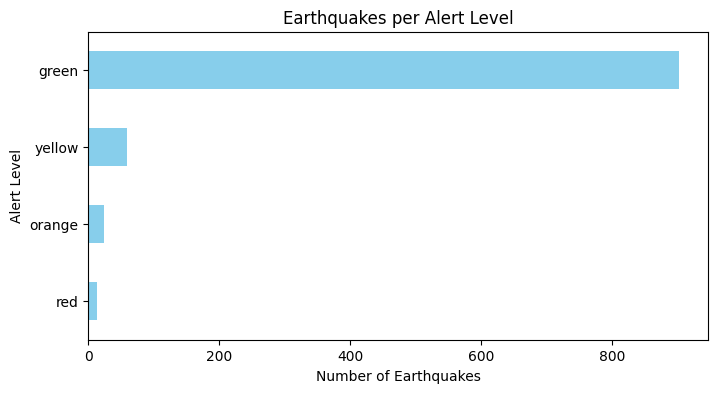

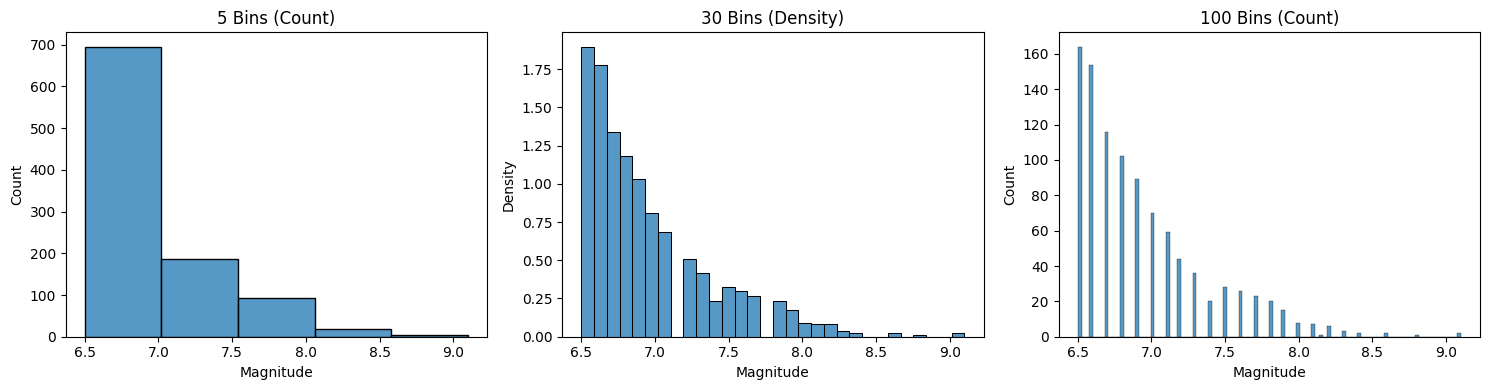

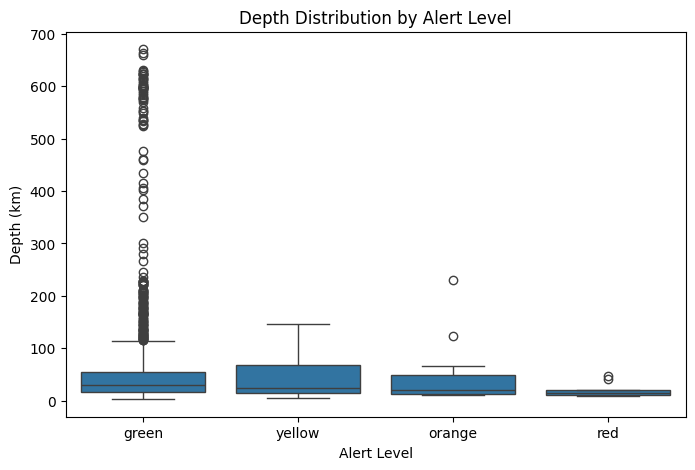

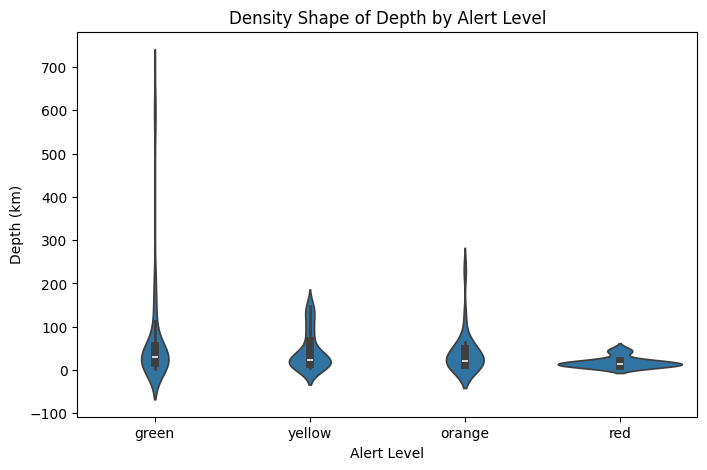

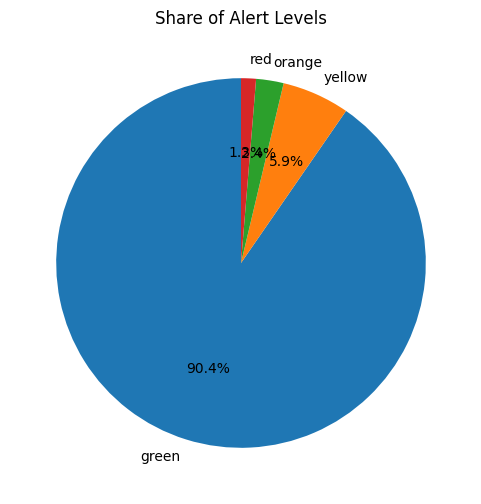

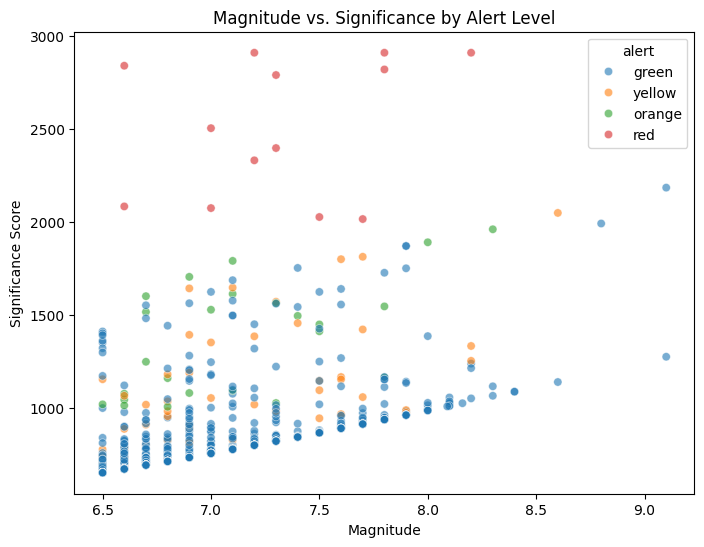

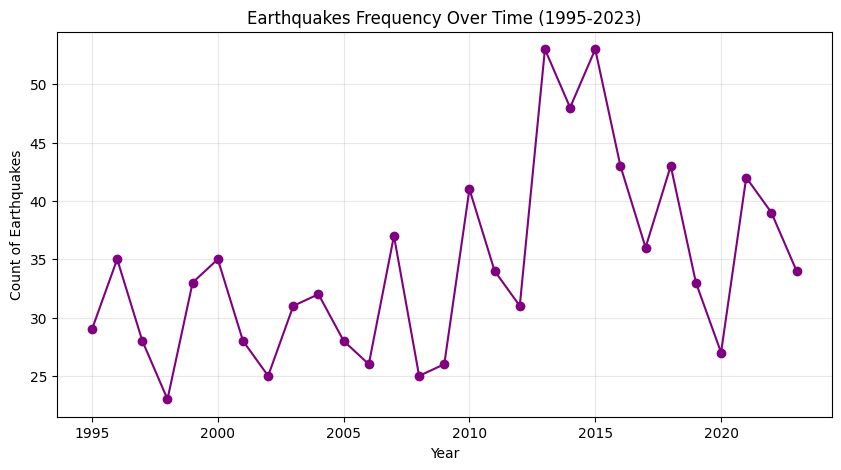

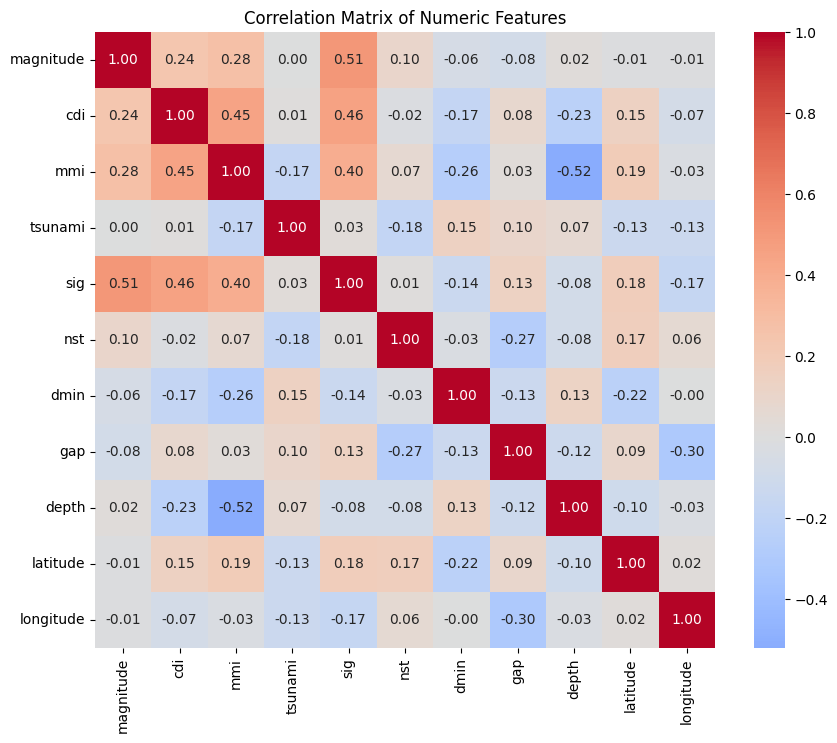

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Load and Clean Data (Continuing from Lab 1)
df = pd.read_csv('earthquake_1995-2023.csv')
df = df.drop_duplicates(subset=["title", "date_time"], keep="first").reset_index(drop=True)
for col in ["cdi", "gap", "nst", "dmin"]:
    df[col] = df[col].replace(0, np.nan)
df['cdi'] = df['cdi'].fillna(df['cdi'].mean())
df['nst'] = df['nst'].fillna(df['nst'].mean())
df['gap'] = df['gap'].fillna(df['gap'].median())
df['dmin'] = df['dmin'].fillna(df['dmin'].median())
df['alert'] = df['alert'].fillna(df['alert'].mode()[0])
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
df['year'] = df['date_time'].dt.year

# 1. Bar Chart (Sorted & Horizontal)
plt.figure(figsize=(8, 4))
df['alert'].value_counts().sort_values().plot(kind='barh', color='skyblue')
plt.title('Earthquakes per Alert Level')
plt.xlabel('Number of Earthquakes')
plt.ylabel('Alert Level')
plt.show()

# 2. Histogram (3 Bin variations + Density option)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['magnitude'], bins=5, ax=axes[0]).set(title='5 Bins (Count)', xlabel='Magnitude')
sns.histplot(df['magnitude'], bins=30, stat='density', ax=axes[1]).set(title='30 Bins (Density)', xlabel='Magnitude')
sns.histplot(df['magnitude'], bins=100, ax=axes[2]).set(title='100 Bins (Count)', xlabel='Magnitude')
plt.tight_layout()
plt.show()

# 3. Box Plot (Depth by Alert)
plt.figure(figsize=(8, 5))
sns.boxplot(x='alert', y='depth', data=df)
plt.title('Depth Distribution by Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Depth (km)')
plt.show()

# 4. Violin Plot (Depth by Alert)
plt.figure(figsize=(8, 5))
sns.violinplot(x='alert', y='depth', data=df)
plt.title('Density Shape of Depth by Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Depth (km)')
plt.show()

# 5. Pie Chart
plt.figure(figsize=(6, 6))
alert_counts = df['alert'].value_counts()
plt.pie(alert_counts, labels=alert_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Alert Levels')
plt.show()

# 6. Scatter Plot (Magnitude vs. Significance with Color coding)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='magnitude', y='sig', hue='alert', alpha=0.6, data=df)
plt.title('Magnitude vs. Significance by Alert Level')
plt.xlabel('Magnitude')
plt.ylabel('Significance Score')
plt.show()

# 7. Line Chart (Trend over time)
plt.figure(figsize=(10, 5))
yearly_counts = df.groupby('year').size()
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', linestyle='-', color='purple')
plt.title('Earthquakes Frequency Over Time (1995-2023)')
plt.xlabel('Year')
plt.ylabel('Count of Earthquakes')
plt.grid(True, alpha=0.3)
plt.show()

# 8. Heatmap (Correlation Matrix)
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['year'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

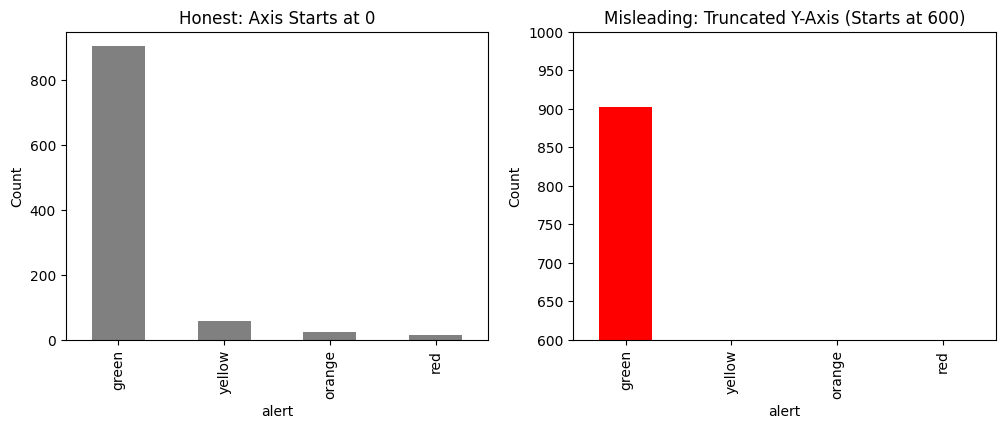

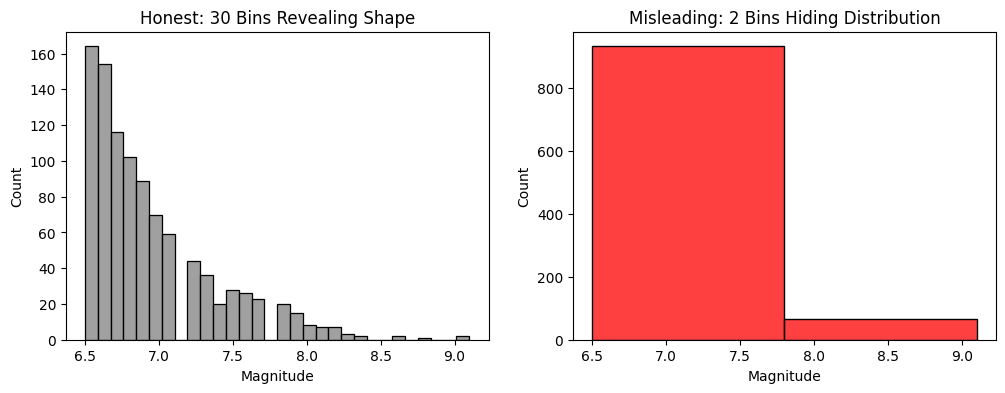

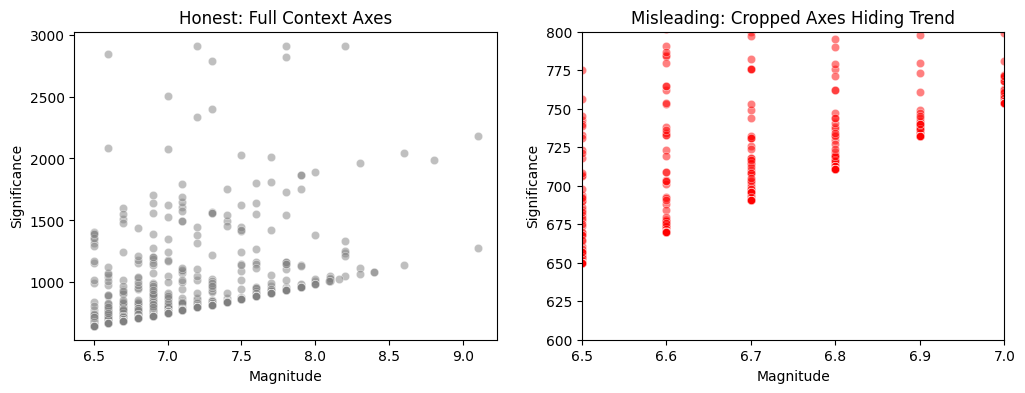

In [ ]:
# Pair 1: Bar Chart (Truncated Axis)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['alert'].value_counts().plot(kind='bar', ax=axes[0], color='gray')
axes[0].set_title('Honest: Axis Starts at 0')
axes[0].set_ylabel('Count')

df['alert'].value_counts().plot(kind='bar', ax=axes[1], color='red')
axes[1].set_ylim(600, 1000) # Truncation
axes[1].set_title('Misleading: Truncated Y-Axis (Starts at 600)')
axes[1].set_ylabel('Count')
plt.show()

# Pair 2: Histogram (Too Few Bins)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['magnitude'], bins=30, ax=axes[0], color='gray')
axes[0].set_title('Honest: 30 Bins Revealing Shape')
axes[0].set_xlabel('Magnitude')

sns.histplot(df['magnitude'], bins=2, ax=axes[1], color='red')
axes[1].set_title('Misleading: 2 Bins Hiding Distribution')
axes[1].set_xlabel('Magnitude')
plt.show()

# Pair 3: Scatter Plot (Cropped Axes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='magnitude', y='sig', data=df, ax=axes[0], color='gray', alpha=0.5)
axes[0].set_title('Honest: Full Context Axes')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Significance')

sns.scatterplot(x='magnitude', y='sig', data=df, ax=axes[1], color='red', alpha=0.5)
axes[1].set_xlim(6.5, 7.0)
axes[1].set_ylim(600, 800)
axes[1].set_title('Misleading: Cropped Axes Hiding Trend')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Significance')
plt.show()